In [31]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
def get_dataloaders(N_percent, batch_size=128):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

    N = int(len(dataset) * N_percent / 100)
    labeled_dataset, _ = random_split(dataset, [N, len(dataset) - N])

    labeled_loader = DataLoader(labeled_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    return labeled_loader, test_loader

In [4]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)

In [5]:
class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet, self).__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU()

        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        layers = []
        layers.append(block(self.in_channels, out_channels, stride))
        self.in_channels = out_channels
        for _ in range(1, num_blocks):
            layers.append(block(self.in_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avg_pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

In [6]:
def get_resnet18(feature_extractor=False):
    model = ResNet(ResidualBlock, [2, 2, 2, 2])
    if feature_extractor:
        for param in model.parameters():
            param.requires_grad = False
    model.fc = nn.Linear(512, 10)
    if feature_extractor:
        for param in model.fc.parameters():
            param.requires_grad = True
    return model

In [7]:
class SimCLR(nn.Module):
    def __init__(self, base_model, projection_dim=128):
        super(SimCLR, self).__init__()
        self.encoder = base_model
        self.pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.projection = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, projection_dim)
        )

    def forward(self, x):
        features = self.encoder(x)
        if len(features.shape) == 4:
            features = self.pooling(features).squeeze(-1).squeeze(-1)
        projections = self.projection(features)
        return F.normalize(projections, dim=1)

## Обучение SimCLR


In [17]:
def train_classifier(model, train_loader, test_loader, epochs=10, lr=0.001):
    """
    Обучает классификатор на размеченных данных с мониторингом метрик
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    model.train()

    print("Начало обучения классификатора...")

    for epoch in range(epochs):
        train_loss = 0.0
        correct = 0
        total = 0

        for batch_idx, (x, y) in enumerate(train_loader):
            x, y = x.cuda(), y.cuda()

            # Прямой проход
            outputs = model(x)
            loss = criterion(outputs, y)

            # Обратный проход
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Сбор статистики
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()

        # Вывод метрик эпохи
        epoch_loss = train_loss / len(train_loader)
        accuracy = 100. * correct / total
        print(f"Epoch: [{epoch+1}/{epochs}] | "
              f"Loss: {epoch_loss:.4f} | "
              f"Accuracy: {accuracy:.2f}%")

In [28]:
def train_simclr(model, dataloader, optimizer, temperature=0.5, epochs=10):
    """
    Обучает модель с использованием контрастивного обучения SimCLR
    """
    model.train()
    criterion = nn.CrossEntropyLoss()

    print("Начало контрастивного обучения (SimCLR)...")

    for epoch in range(epochs):
        epoch_loss = 0.0

        for (x_i, _) in tqdm(dataloader, desc=f"Epoch: {epoch+1}/{epochs}"):
            x_i = x_i.cuda()

            # Аугментации для контрастивного обучения
            x_j = torch.flip(x_i, dims=[-1])  # Горизонтальное отражение

            # Получение проекций
            z_i = model(x_i)
            z_j = model(x_j)

            # Расчет контрастивной потери
            logits = torch.matmul(z_i, z_j.T) / temperature
            labels = torch.arange(len(x_i)).cuda()
            loss = criterion(logits, labels)

            # Оптимизация
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)
        print(f"Epoch: [{epoch+1}/{epochs}] | Avg Loss: {avg_loss:.4f}")


In [18]:
print("Загрузка данных и инициализация модели...")
labeled_loader, test_loader = get_dataloaders(N_percent=50)
model = get_resnet18(feature_extractor=False).cuda()

print("\nОбучение классификатора на 50% размеченных данных")
print("=" * 50)
train_classifier(model, labeled_loader, test_loader, epochs=10)

Загрузка данных и инициализация модели...

Обучение классификатора на 50% размеченных данных
Начало обучения классификатора...
Epoch: [1/10] | Loss: 1.5413 | Accuracy: 43.79%
Epoch: [2/10] | Loss: 1.0776 | Accuracy: 60.92%
Epoch: [3/10] | Loss: 0.8443 | Accuracy: 69.82%
Epoch: [4/10] | Loss: 0.6908 | Accuracy: 75.82%
Epoch: [5/10] | Loss: 0.5575 | Accuracy: 80.36%
Epoch: [6/10] | Loss: 0.4443 | Accuracy: 84.44%
Epoch: [7/10] | Loss: 0.3458 | Accuracy: 87.72%
Epoch: [8/10] | Loss: 0.2584 | Accuracy: 91.06%
Epoch: [9/10] | Loss: 0.1899 | Accuracy: 93.28%
Epoch: [10/10] | Loss: 0.1384 | Accuracy: 95.22%


## Обучение без предобучения feature extractor

In [48]:
# Добавляем сбор метрик для анализа
results = {}

for N_percent in [100, 50, 10]:
    print(f"\n{'-'*50}")
    print(f"Эксперимент: обучение на {N_percent}% размеченных данных")
    print(f"{'-'*50}")

    # Получаем данные и модель
    labeled_loader, test_loader = get_dataloaders(N_percent=N_percent)
    model = get_resnet18(feature_extractor=False).cuda()

    # Обучаем классификатор
    final_accuracy = train_classifier(
        model,
        labeled_loader,
        test_loader,
        epochs=10
    )

    # Сохраняем результаты
    results[N_percent] = final_accuracy


--------------------------------------------------
Эксперимент: обучение на 100% размеченных данных
--------------------------------------------------
Начало обучения классификатора...
Epoch: [1/10] | Loss: 1.3545 | Accuracy: 50.30%
Epoch: [2/10] | Loss: 0.8237 | Accuracy: 70.72%
Epoch: [3/10] | Loss: 0.6046 | Accuracy: 78.61%
Epoch: [4/10] | Loss: 0.4710 | Accuracy: 83.51%
Epoch: [5/10] | Loss: 0.3633 | Accuracy: 87.23%
Epoch: [6/10] | Loss: 0.2805 | Accuracy: 90.07%
Epoch: [7/10] | Loss: 0.2058 | Accuracy: 92.73%
Epoch: [8/10] | Loss: 0.1548 | Accuracy: 94.56%
Epoch: [9/10] | Loss: 0.1096 | Accuracy: 96.19%
Epoch: [10/10] | Loss: 0.0791 | Accuracy: 97.23%

--------------------------------------------------
Эксперимент: обучение на 50% размеченных данных
--------------------------------------------------
Начало обучения классификатора...
Epoch: [1/10] | Loss: 1.5945 | Accuracy: 41.36%
Epoch: [2/10] | Loss: 1.1267 | Accuracy: 59.52%
Epoch: [3/10] | Loss: 0.9015 | Accuracy: 67.65%
Epoc

Количество размеченных данных существенно влияет на качество модели. Наибольший провал производительности наблюдается при использовании 10% данных"

In [29]:
# Контрастивное предобучение на всех данных
print("=" * 60)
print("ЭТАП 1: КОНТРАСТИВНОЕ ПРЕДОБУЧЕНИЕ (SimCLR)")
print("=" * 60)

print("Загрузка полного набора данных (100% без разметки)...")
full_loader, _ = get_dataloaders(N_percent=100)

print("Инициализация модели SimCLR...")
resnet_backbone = get_resnet18(feature_extractor=False)

original_fc = resnet_backbone.fc
resnet_backbone.fc = nn.Identity()

print("Создание модели SimCLR...")
simclr_model = SimCLR(resnet_backbone).cuda()

print("Настройка оптимизатора...")
optimizer = torch.optim.Adam(simclr_model.parameters(), lr=0.001)

print(f"\nКонфигурация обучения:")
print(f"- Размер батча: {full_loader.batch_size}")
print(f"- Архитектура: ResNet18 + проекция SimCLR")

print("\nНачало контрастивного предобучения...")
train_simclr(simclr_model, full_loader, optimizer, epochs=10)

# Восстанавливаем оригинальный классификатор после предобучения
resnet_backbone.fc = original_fc

print("\n" + "=" * 60)
print("РЕЗУЛЬТАТЫ ПРЕДОБУЧЕНИЯ:")
print("=" * 60)
print("✓ Модель SimCLR успешно предобучена на 100% данных")
print("✓ Исходная архитектура ResNet восстановлена")
print("✓ Модель готова для трансферного обучения")

ЭТАП 1: КОНТРАСТИВНОЕ ПРЕДОБУЧЕНИЕ (SimCLR)
Загрузка полного набора данных (100% без разметки)...
Инициализация модели SimCLR...
Создание модели SimCLR...
Настройка оптимизатора...

Конфигурация обучения:
- Размер батча: 128
- Архитектура: ResNet18 + проекция SimCLR

Начало контрастивного предобучения...
Начало контрастивного обучения (SimCLR)...


Epoch: 1/10: 100%|██████████| 391/391 [01:25<00:00,  4.59it/s]


Epoch: [1/10] | Avg Loss: 2.9969


Epoch: 2/10: 100%|██████████| 391/391 [01:25<00:00,  4.60it/s]


Epoch: [2/10] | Avg Loss: 2.9446


...

Epoch: [8/10] | Avg Loss: 2.9283


Epoch: 9/10: 100%|██████████| 391/391 [01:24<00:00,  4.61it/s]


Epoch: [9/10] | Avg Loss: 2.9267


Epoch: 10/10: 100%|██████████| 391/391 [01:24<00:00,  4.61it/s]

Epoch: [10/10] | Avg Loss: 2.9278

РЕЗУЛЬТАТЫ ПРЕДОБУЧЕНИЯ:
✓ Модель SimCLR успешно предобучена на 100% данных
✓ Исходная архитектура ResNet восстановлена
✓ Модель готова для трансферного обучения


In [30]:
for N_percent in [100, 50, 10]:
    print(f"\n{'='*60}")
    print(f"Трансферное обучение с предобученным энкодером и {N_percent}% размеченных данных")
    print(f"{'='*60}")

    labeled_loader, test_loader = get_dataloaders(N_percent=N_percent)

    # Инициализация модели с предобученными весами
    resnet_pretrained = get_resnet18(feature_extractor=True).cuda()
    resnet_pretrained.load_state_dict(simclr_model.encoder.state_dict(), strict=False)

    print(f"Загружены предобученные веса SimCLR")
    print(f"Размер обучающей выборки: {len(labeled_loader.dataset)} примеров")
    print(f"Размер тестовой выборки: {len(test_loader.dataset)} примеров")

    # Обучение классификатора
    train_classifier(resnet_pretrained, labeled_loader, test_loader, epochs=10)

    print(f"\nРезультаты для {N_percent}% данных:")
    print(f"Модель успешно дообучена с использованием предобученных признаков")
    print(f"Использовано {N_percent}% размеченных данных из общего набора")


Трансферное обучение с предобученным энкодером и 100% размеченных данных
Загружены предобученные веса SimCLR
Размер обучающей выборки: 50000 примеров
Размер тестовой выборки: 10000 примеров
Начало обучения классификатора...
Epoch: [1/10] | Loss: 1.9696 | Accuracy: 28.28%
Epoch: [2/10] | Loss: 1.9199 | Accuracy: 30.15%
Epoch: [3/10] | Loss: 1.9041 | Accuracy: 30.66%
Epoch: [4/10] | Loss: 1.8934 | Accuracy: 31.43%
Epoch: [5/10] | Loss: 1.8845 | Accuracy: 31.55%
Epoch: [6/10] | Loss: 1.8744 | Accuracy: 31.99%
Epoch: [7/10] | Loss: 1.8680 | Accuracy: 32.43%
Epoch: [8/10] | Loss: 1.8623 | Accuracy: 32.80%
Epoch: [9/10] | Loss: 1.8586 | Accuracy: 32.83%
Epoch: [10/10] | Loss: 1.8500 | Accuracy: 33.19%

Результаты для 100% данных:
Модель успешно дообучена с использованием предобученных признаков
Использовано 100% размеченных данных из общего набора

Трансферное обучение с предобученным энкодером и 50% размеченных данных
Загружены предобученные веса SimCLR
Размер обучающей выборки: 25000 прим

Большой разницы нет в качестве для 100, 50 и 10 процентов разметки

In [35]:
# Глобальные списки для сохранения результатов
results = []

def train_classifier_with_metrics(model, train_loader, test_loader, epochs=10, lr=0.001, label=""):
    """
    Обучает классификатор с отслеживанием метрик и сохранением результатов
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    model.train()

    train_losses = []
    accuracies = []

    print(f"Начало обучения классификатора: {label}")
    print(f"Размер обучающей выборки: {len(train_loader.dataset)} примеров")
    print(f"Количество эпох: {epochs}")

    for epoch in range(epochs):
        train_loss = 0.0
        correct = 0
        total = 0

        for x, y in train_loader:
            x, y = x.cuda(), y.cuda()

            # Прямой проход
            outputs = model(x)
            loss = criterion(outputs, y)

            # Обратный проход
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Сбор статистики
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()

        # Расчет метрик эпохи
        epoch_loss = train_loss / len(train_loader)
        accuracy = 100. * correct / total
        train_losses.append(epoch_loss)
        accuracies.append(accuracy)

        print(f"[{label}] Epoch [{epoch+1}/{epochs}] | "
              f"Loss: {epoch_loss:.4f} | "
              f"Accuracy: {accuracy:.2f}%")

    # Сохраняем финальные метрики
    max_accuracy = max(accuracies)
    final_accuracy = accuracies[-1]
    final_loss = train_losses[-1]

    results.append({
        "label": label,
        "max_accuracy": max_accuracy,
        "final_accuracy": final_accuracy,
        "final_loss": final_loss,
        "epochs": epochs
    })

    print(f"\nРезультаты обучения ({label}):")
    print(f"Max accuracy: {max_accuracy:.2f}%")
    print(f"Final accuracy: {final_accuracy:.2f}%")
    print(f"Final loss: {final_loss:.4f}")

    return train_losses, accuracies

In [36]:
# Функция для визуализации графиков
def plot_metrics(metrics, title, ylabel, xlabel="Epochs"):
    plt.figure(figsize=(10, 6))
    for label, values in metrics.items():
        plt.plot(values, label=label)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()

## Without pretraining


In [38]:
loss_metrics = {}
accuracy_metrics = {}

for N_percent in [100, 50, 10]:
    print(f"\n{'='*60}")
    print(f"Обучение с нуля на {N_percent}% размеченных данных")
    print(f"{'='*60}")

    # Загрузка данных и инициализация модели
    labeled_loader, test_loader = get_dataloaders(N_percent=N_percent)
    model = get_resnet18(feature_extractor=False).cuda()

    print(f"Загружено {len(labeled_loader.dataset)} обучающих примеров")
    print(f"Загружено {len(test_loader.dataset)} тестовых примеров")

    # Обучение модели
    train_losses, accuracies = train_classifier_with_metrics(
        model, labeled_loader, test_loader, epochs=10,
        label=f"С нуля {N_percent}%"
    )

    # Сохранение метрик
    loss_metrics[f"С нуля {N_percent}%"] = train_losses
    accuracy_metrics[f"С нуля {N_percent}%"] = accuracies

    print(f"\nЗавершено обучение на {N_percent}% данных")
    print(f"Max accuracy: {max(accuracies):.2f}%")
    print(f"Final accuracy: {accuracies[-1]:.2f}%")

# Итоговый вывод по всем экспериментам
print(f"\n{'='*60}")
print("ИТОГИ ЭКСПЕРИМЕНТОВ С ОБУЧЕНИЕМ С НУЛЯ")
print(f"{'='*60}")
for label in accuracy_metrics:
    max_acc = max(accuracy_metrics[label])
    final_acc = accuracy_metrics[label][-1]
    print(f"{label}: Max accuracy = {max_acc:.2f}%, Final accuracy = {final_acc:.2f}%")


Обучение с нуля на 100% размеченных данных
Загружено 50000 обучающих примеров
Загружено 10000 тестовых примеров
Начало обучения классификатора: С нуля 100%
Размер обучающей выборки: 50000 примеров
Количество эпох: 10
[С нуля 100%] Epoch [1/10] | Loss: 1.3647 | Accuracy: 50.04%
[С нуля 100%] Epoch [2/10] | Loss: 0.8540 | Accuracy: 69.77%
[С нуля 100%] Epoch [3/10] | Loss: 0.6192 | Accuracy: 78.29%
[С нуля 100%] Epoch [4/10] | Loss: 0.4810 | Accuracy: 83.15%
[С нуля 100%] Epoch [5/10] | Loss: 0.3752 | Accuracy: 86.84%
[С нуля 100%] Epoch [6/10] | Loss: 0.2892 | Accuracy: 89.78%
[С нуля 100%] Epoch [7/10] | Loss: 0.2095 | Accuracy: 92.61%
[С нуля 100%] Epoch [8/10] | Loss: 0.1527 | Accuracy: 94.59%
[С нуля 100%] Epoch [9/10] | Loss: 0.1060 | Accuracy: 96.29%
[С нуля 100%] Epoch [10/10] | Loss: 0.0839 | Accuracy: 97.01%

Результаты обучения (С нуля 100%):
Max accuracy: 97.01%
Final accuracy: 97.01%
Final loss: 0.0839

Завершено обучение на 100% данных
Max accuracy: 97.01%
Final accuracy: 

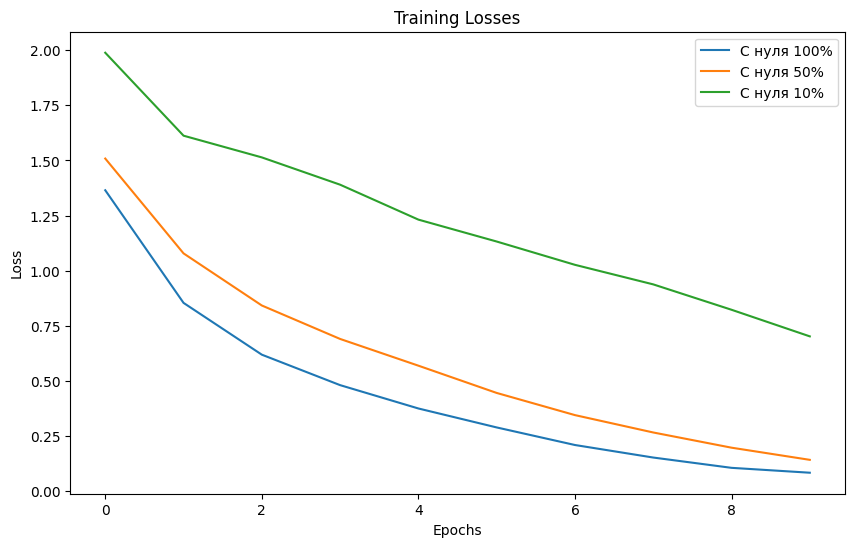

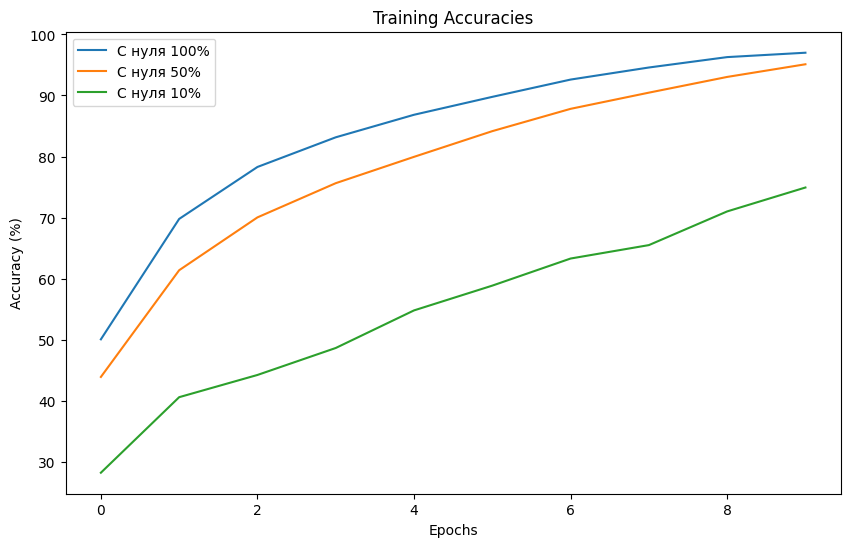

In [39]:
plot_metrics(loss_metrics, title="Training Losses", ylabel="Loss")
plot_metrics(accuracy_metrics, title="Training Accuracies", ylabel="Accuracy (%)")

## Pretrained models

In [43]:
# Контрастивное предобучение на всех данных
print("=" * 60)
print("ЭТАП 1: КОНТРАСТИВНОЕ ПРЕДОБУЧЕНИЕ (SimCLR)")
print("=" * 60)

print("Загрузка полного набора данных (100% без разметки)...")
full_loader, _ = get_dataloaders(N_percent=100)

print("Инициализация модели SimCLR...")
resnet_backbone = get_resnet18(feature_extractor=False)

original_fc = resnet_backbone.fc
resnet_backbone.fc = nn.Identity()

print("Создание модели SimCLR...")
simclr_model = SimCLR(resnet_backbone).cuda()

print("Настройка оптимизатора...")
optimizer = torch.optim.Adam(simclr_model.parameters(), lr=0.001)

print(f"\nКонфигурация обучения:")
print(f"- Размер батча: {full_loader.batch_size}")
print(f"- Архитектура: ResNet18 + проекция SimCLR")

print("\nНачало контрастивного предобучения...")
train_simclr(simclr_model, full_loader, optimizer, epochs=10)

# Восстанавливаем оригинальный классификатор после предобучения
resnet_backbone.fc = original_fc

print("\n" + "=" * 60)
print("РЕЗУЛЬТАТЫ ПРЕДОБУЧЕНИЯ:")
print("=" * 60)
print("✓ Модель SimCLR успешно предобучена на 100% данных")
print("✓ Исходная архитектура ResNet восстановлена")
print("✓ Модель готова для трансферного обучения")
print("✓ Веса энкодера сохранены для последующего использования")

ЭТАП 1: КОНТРАСТИВНОЕ ПРЕДОБУЧЕНИЕ (SimCLR)
Загрузка полного набора данных (100% без разметки)...
Инициализация модели SimCLR...
Создание модели SimCLR...
Настройка оптимизатора...

Конфигурация обучения:
- Размер батча: 128
- Архитектура: ResNet18 + проекция SimCLR

Начало контрастивного предобучения...
Начало контрастивного обучения (SimCLR)...


Epoch: 1/10: 100%|██████████| 391/391 [01:25<00:00,  4.60it/s]


Epoch: [1/10] | Avg Loss: 3.0077


Epoch: 2/10: 100%|██████████| 391/391 [01:24<00:00,  4.60it/s]


Epoch: [2/10] | Avg Loss: 2.9475


...

Epoch: [8/10] | Avg Loss: 2.9297


Epoch: 9/10: 100%|██████████| 391/391 [01:24<00:00,  4.60it/s]


Epoch: [9/10] | Avg Loss: 2.9289


Epoch: 10/10: 100%|██████████| 391/391 [01:24<00:00,  4.61it/s]

Epoch: [10/10] | Avg Loss: 2.9312

РЕЗУЛЬТАТЫ ПРЕДОБУЧЕНИЯ:
✓ Модель SimCLR успешно предобучена на 100% данных
✓ Исходная архитектура ResNet восстановлена
✓ Модель готова для трансферного обучения
✓ Веса энкодера сохранены для последующего использования


## Pretrained + feature extractor

In [44]:
# Эксперимент с трансферным обучением на различных объемах размеченных данных
for N_percent in [100, 50, 10]:
    print(f"\n{'='*60}")
    print(f"ТРАНСФЕРНОЕ ОБУЧЕНИЕ: {N_percent}% РАЗМЕЧЕННЫХ ДАННЫХ")
    print(f"{'='*60}")

    # Загрузка данных для текущего эксперимента
    print(f"Загрузка {N_percent}% размеченных данных...")
    labeled_loader, test_loader = get_dataloaders(N_percent=N_percent)

    # Инициализация модели с предобученным энкодером
    print("Инициализация модели с предобученными весами SimCLR...")
    resnet_pretrained = get_resnet18(feature_extractor=True).cuda()

    # Загрузка весов предобученного энкодера (игнорируя несовпадающие слои)
    resnet_pretrained.load_state_dict(simclr_model.encoder.state_dict(), strict=False)
    print("Веса энкодера успешно загружены из предобученной модели SimCLR")

    # Обучение классификатора с метриками
    print(f"Запуск обучения классификатора на {N_percent}% данных...")
    train_losses, accuracies = train_classifier_with_metrics(
        resnet_pretrained, labeled_loader, test_loader, epochs=10,
        label=f"Pretrained {N_percent}%"
    )

    # Сохранение метрик для последующего анализа
    loss_metrics[f"Pretrained {N_percent}%"] = train_losses
    accuracy_metrics[f"Pretrained {N_percent}%"] = accuracies

    print(f"\nРезультаты для {N_percent}% данных:")
    print(f"Максимальная точность: {max(accuracies):.2f}%")
    print(f"Финальная точность: {accuracies[-1]:.2f}%")
    print(f"Трансферное обучение завершено для {N_percent}% данных")

# Итоговый вывод по всем экспериментам трансферного обучения
print(f"\n{'='*60}")
print("ИТОГИ ТРАНСФЕРНОГО ОБУЧЕНИЯ С ПРЕДОБУЧЕННЫМ ЭНКОДЕРОМ")
print(f"{'='*60}")
for label in [f"Pretrained {p}%" for p in [100, 50, 10]]:
    if label in accuracy_metrics:
        max_acc = max(accuracy_metrics[label])
        final_acc = accuracy_metrics[label][-1]
        print(f"{label}: Максимальная точность = {max_acc:.2f}%, Финальная точность = {final_acc:.2f}%")


ТРАНСФЕРНОЕ ОБУЧЕНИЕ: 100% РАЗМЕЧЕННЫХ ДАННЫХ
Загрузка 100% размеченных данных...
Инициализация модели с предобученными весами SimCLR...
Веса энкодера успешно загружены из предобученной модели SimCLR
Запуск обучения классификатора на 100% данных...
Начало обучения классификатора: Pretrained 100%
Размер обучающей выборки: 50000 примеров
Количество эпох: 10
[Pretrained 100%] Epoch [1/10] | Loss: 2.0498 | Accuracy: 24.93%
[Pretrained 100%] Epoch [2/10] | Loss: 2.0009 | Accuracy: 27.06%
[Pretrained 100%] Epoch [3/10] | Loss: 1.9889 | Accuracy: 27.70%
[Pretrained 100%] Epoch [4/10] | Loss: 1.9799 | Accuracy: 27.85%
[Pretrained 100%] Epoch [5/10] | Loss: 1.9635 | Accuracy: 28.60%
[Pretrained 100%] Epoch [6/10] | Loss: 1.9577 | Accuracy: 29.11%
[Pretrained 100%] Epoch [7/10] | Loss: 1.9552 | Accuracy: 29.24%
[Pretrained 100%] Epoch [8/10] | Loss: 1.9484 | Accuracy: 29.58%
[Pretrained 100%] Epoch [9/10] | Loss: 1.9413 | Accuracy: 29.50%
[Pretrained 100%] Epoch [10/10] | Loss: 1.9436 | Accurac

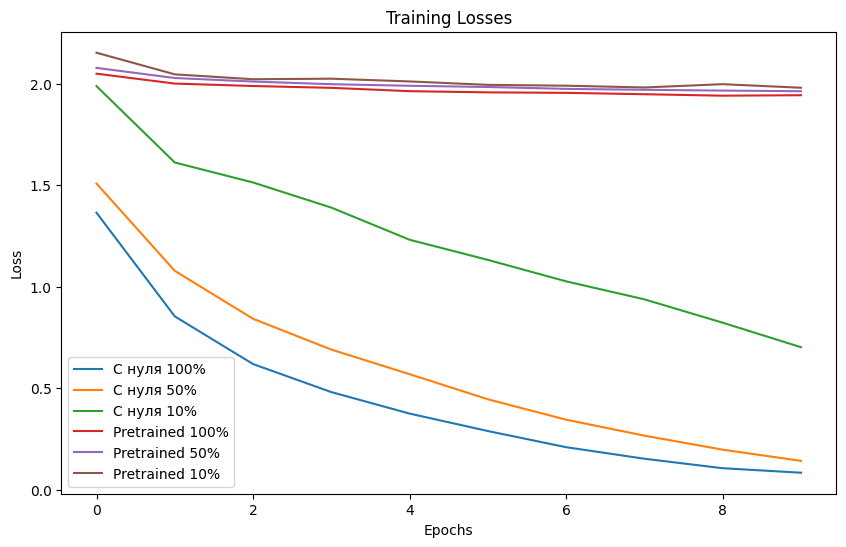

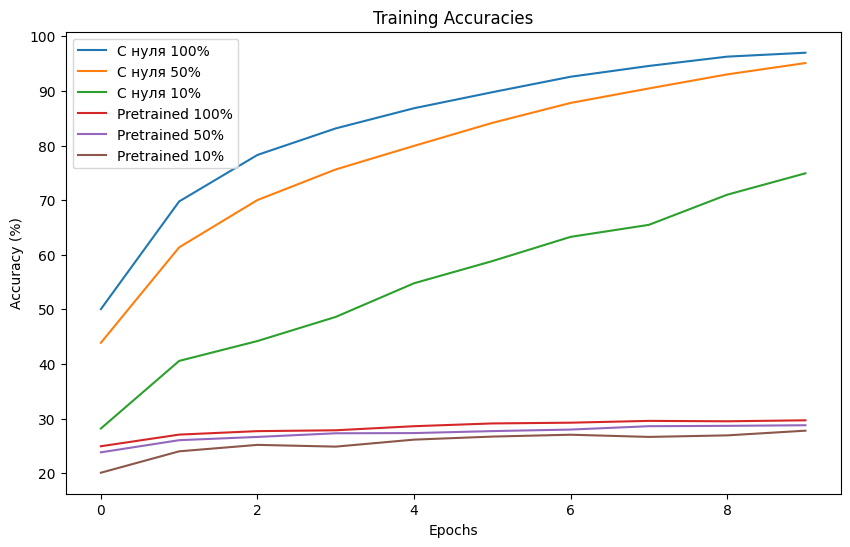

In [45]:
plot_metrics(loss_metrics, title="Training Losses", ylabel="Loss")
plot_metrics(accuracy_metrics, title="Training Accuracies", ylabel="Accuracy (%)")

## Результаты

In [46]:
df_results = pd.DataFrame(results)
print(df_results)

             label  max_accuracy  final_accuracy  final_loss  epochs
0      С нуля 100%        97.008          97.008    0.083886      10
1       С нуля 50%        95.116          95.116    0.142293      10
2       С нуля 10%        74.920          74.920    0.702148      10
3  Pretrained 100%        29.682          29.682    1.943596      10
4   Pretrained 50%        28.776          28.776    1.963300      10
5   Pretrained 10%        27.780          27.780    1.980431      10


In [47]:
md_table = df_results.to_markdown(index=False)
print(md_table)

| label           |   max_accuracy |   final_accuracy |   final_loss |   epochs |
|:----------------|---------------:|-----------------:|-------------:|---------:|
| С нуля 100%     |         97.008 |           97.008 |     0.083886 |       10 |
| С нуля 50%      |         95.116 |           95.116 |     0.142293 |       10 |
| С нуля 10%      |         74.92  |           74.92  |     0.702148 |       10 |
| Pretrained 100% |         29.682 |           29.682 |     1.9436   |       10 |
| Pretrained 50%  |         28.776 |           28.776 |     1.9633   |       10 |
| Pretrained 10%  |         27.78  |           27.78  |     1.98043  |       10 |
